# Seasonal Agriculture Performance Analysis

### Major Project – VOIS AICTE

**Objective:**  
To analyze agricultural performance across different seasons and identify
meaningful patterns, trends, relationships, and variations in agricultural
production, resource usage, environmental conditions, and economic outcomes.

**Dataset:** Seasonal Agriculture Performance Dataset

## 1. Introduction

Agricultural performance is influenced by seasonal environmental conditions,
farming practices, resource availability, crop characteristics, and economic
factors. This project analyzes agricultural data across different seasons to
identify patterns and differences in yield, production, resource usage,
environmental conditions, and profitability.

The analysis aims to understand how agricultural performance changes across
Kharif, Rabi, and Zaid seasons and to identify factors associated with these
seasonal variations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [97]:
import pandas as pd

df = pd.read_csv("../data/raw/seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [98]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 4000
Columns: 28
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 

In [23]:
print("Columns in the dataset:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Columns in the dataset:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [24]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Series([], dtype: int64)


In [25]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [26]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [28]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


--- Farm_ID ---
Unique values: 4000
Farm_ID
SF10001    1
SF10002    1
SF10003    1
SF10004    1
SF10005    1
SF10006    1
SF10007    1
SF10008    1
SF10009    1
SF10010    1
Name: count, dtype: int64

--- State ---
Unique values: 8
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- District ---
Unique values: 10
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

--- Crop ---
Unique values: 8
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Unique values: 3
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Met

## 2. Data Quality Assessment

The dataset contains 4,000 records and 28 variables covering agricultural,
environmental, resource, production, and economic characteristics.

An initial data quality assessment was performed to identify missing values
and duplicate records. The dataset contains no missing values and no duplicate
rows. Therefore, no missing-value imputation or duplicate-row removal was
required.

The Farm_ID variable contains 4,000 unique values, indicating that each
observation represents a distinct farm record.

The dataset contains both numerical and categorical variables, allowing
seasonal, crop-wise, regional, environmental, resource, and economic analysis.

In [31]:
categorical_summary = pd.DataFrame({
    "Unique Values": df[categorical_cols].nunique(),
    "Missing Values": df[categorical_cols].isnull().sum()
})

categorical_summary

,Unique Values,Missing Values
Farm_ID,4000,0
State,8,0
District,10,0
Crop,8,0
Season,3,0
Irrigation_Method,4,0


In [32]:
print("States:")
print(sorted(df["State"].unique()))

print("\nSeasons:")
print(sorted(df["Season"].unique()))

print("\nCrops:")
print(sorted(df["Crop"].unique()))

print("\nIrrigation Methods:")
print(sorted(df["Irrigation_Method"].unique()))

States:
['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

Seasons:
['Kharif', 'Rabi', 'Zaid']

Crops:
['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Irrigation Methods:
['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [33]:
season_distribution = df["Season"].value_counts()

print(season_distribution)

print("\nPercentage distribution:")
print((df["Season"].value_counts(normalize=True) * 100).round(2))

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Percentage distribution:
Season
Kharif   44.47
Rabi     40.67
Zaid     14.85
Name: proportion, dtype: float64


In [34]:
numeric_cols = df.select_dtypes(include=np.number).columns

numeric_summary = df[numeric_cols].describe().T

numeric_summary

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,4000.00,600.92,287.19,80.00,371.58,582.00,831.98,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.00,26.51,6.68,8.00,21.80,26.40,31.20,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [35]:
print("Negative values in important agricultural variables:")

checks = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Water_Used_m3",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR"
]

for col in checks:
    print(f"{col}: {(df[col] < 0).sum()}")

Negative values in important agricultural variables:
Farm_Area_Hectares: 0
Rainfall_mm: 0
Avg_Temperature_C: 0
Humidity_pct: 0
Sunlight_Hours_Day: 0
Soil_Moisture_pct: 0
Nitrogen_kg_ha: 0
Phosphorus_kg_ha: 0
Potassium_kg_ha: 0
Fertilizer_kg_ha: 0
Pesticide_Litre_ha: 0
Yield_Tonnes_Ha: 0
Production_Tonnes: 0
Water_Used_m3: 0
Total_Cost_INR: 0
Revenue_INR: 0
Profit_INR: 1966


In [36]:
percentage_cols = [
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Seed_Quality_Score",
    "Disease_Pest_Risk_pct"
]

for col in percentage_cols:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


Humidity_pct
Minimum: 25.0
Maximum: 95.0

Soil_Moisture_pct
Minimum: 8.0
Maximum: 47.0

Seed_Quality_Score
Minimum: 0.65
Maximum: 1.0

Disease_Pest_Risk_pct
Minimum: 5.0
Maximum: 88.9


In [37]:
print("Unique Farm IDs:", df["Farm_ID"].nunique())
print("Total records:", len(df))

if df["Farm_ID"].nunique() == len(df):
    print("Every farm record has a unique Farm_ID.")
else:
    print("Some Farm_ID values are repeated.")

Unique Farm IDs: 4000
Total records: 4000
Every farm record has a unique Farm_ID.


In [38]:
numeric_summary = df.select_dtypes(include=np.number).describe().T

numeric_summary[[
    "min",
    "max",
    "mean",
    "50%",
    "std"
]].round(2)

,min,max,mean,50%,std
Farm_Area_Hectares,0.50,15.00,7.89,7.90,4.22
Rainfall_mm,80.00,1395.20,600.92,582.00,287.19
Avg_Temperature_C,16.20,39.70,26.82,26.90,3.82
Humidity_pct,25.00,95.00,63.21,63.00,11.96
Sunlight_Hours_Day,3.50,11.00,7.32,7.30,1.12
Soil_pH,5.20,8.40,6.70,6.69,0.64
Soil_Moisture_pct,8.00,47.00,26.51,26.40,6.68
Nitrogen_kg_ha,40.00,220.00,120.25,120.10,31.22
Phosphorus_kg_ha,15.00,120.00,57.78,57.50,17.02
Potassium_kg_ha,30.00,200.00,104.76,105.10,27.74


In [39]:
df_clean = df.copy()

In [40]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (4000, 28)
Cleaned shape: (4000, 28)


In [41]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Missing values: 0
Duplicate rows: 0


In [43]:
df_clean.to_csv(
    "../outputs/cleaned_data/cleaned_agriculture_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 5. Data Cleaning and Preparation

The initial data-quality assessment showed that the dataset contains 4,000
records and 28 variables with no missing values or duplicate rows.

The categorical variables were also checked for consistency, while numerical
variables were examined for their ranges and descriptive statistics. No
immediate structural data-quality issues were identified.

Therefore, no missing-value imputation or duplicate-row removal was required.
The dataset was retained without unnecessary modification so that the
subsequent analysis would reflect the original observations.

Potentially unusual observations, particularly in yield and profitability,
will be investigated separately during the outlier and exploratory analysis
rather than being removed automatically.


## 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution
and characteristics of the agricultural dataset before conducting detailed
seasonal comparisons.

The analysis begins by examining the distribution of observations across
seasons, followed by analysis of crop, regional, environmental, resource,
production, and economic characteristics.

The primary focus is to identify patterns and variations that can help answer
the project's key analytical questions.

In [44]:
season_counts = df["Season"].value_counts()

print("Number of records by season:")
print(season_counts)

print("\nPercentage distribution:")
print((df["Season"].value_counts(normalize=True) * 100).round(2))

Number of records by season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Percentage distribution:
Season
Kharif   44.47
Rabi     40.67
Zaid     14.85
Name: proportion, dtype: float64


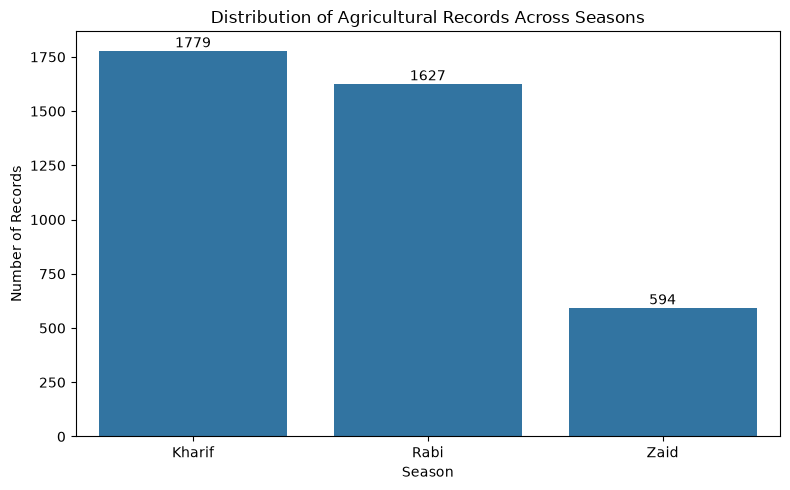

In [106]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Season",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Distribution of Agricultural Records Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../outputs/figures/season_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The dataset contains observations from three agricultural seasons: Kharif,
Rabi, and Zaid. Kharif has the highest number of records, followed by Rabi,
while Zaid has considerably fewer observations.

Kharif accounts for approximately 44.48% of the dataset, Rabi accounts for
40.68%, and Zaid accounts for 14.85%.

Because the number of observations is not evenly distributed across seasons,
seasonal comparisons should primarily use measures such as mean, median,
and distribution rather than relying only on the number of records.

In [46]:
crop_counts = df["Crop"].value_counts()

print("Number of records by crop:")
print(crop_counts)

Number of records by crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


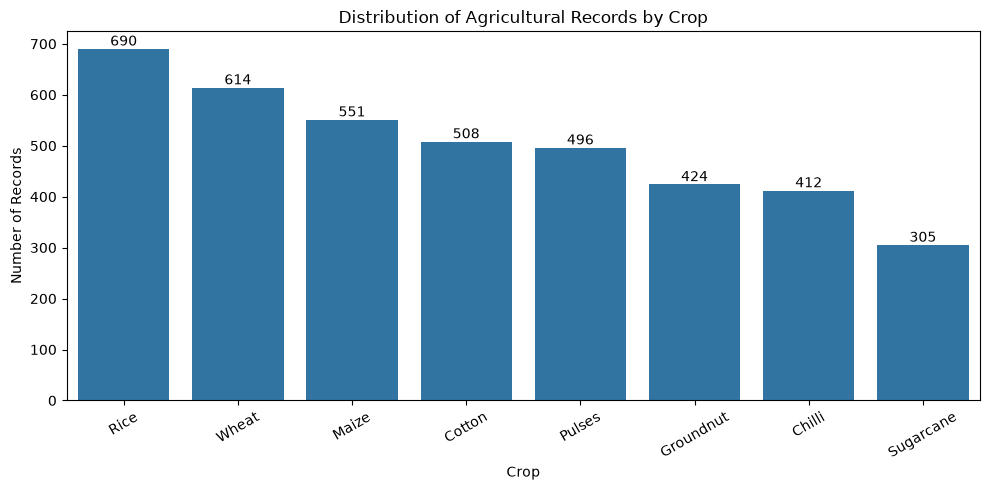

In [107]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="Crop",
    order=df["Crop"].value_counts().index
)

plt.title("Distribution of Agricultural Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../outputs/figures/crop_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
state_counts = df["State"].value_counts()

print("Number of records by state:")
print(state_counts)

Number of records by state:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


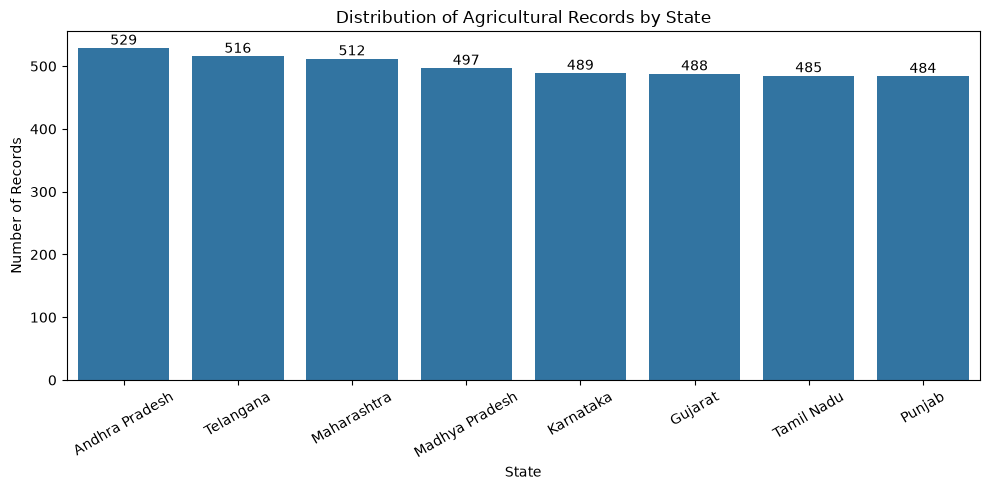

In [108]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="State",
    order=df["State"].value_counts().index
)

plt.title("Distribution of Agricultural Records by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../outputs/figures/state_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
irrigation_counts = df["Irrigation_Method"].value_counts()

print("Number of records by irrigation method:")
print(irrigation_counts)

Number of records by irrigation method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


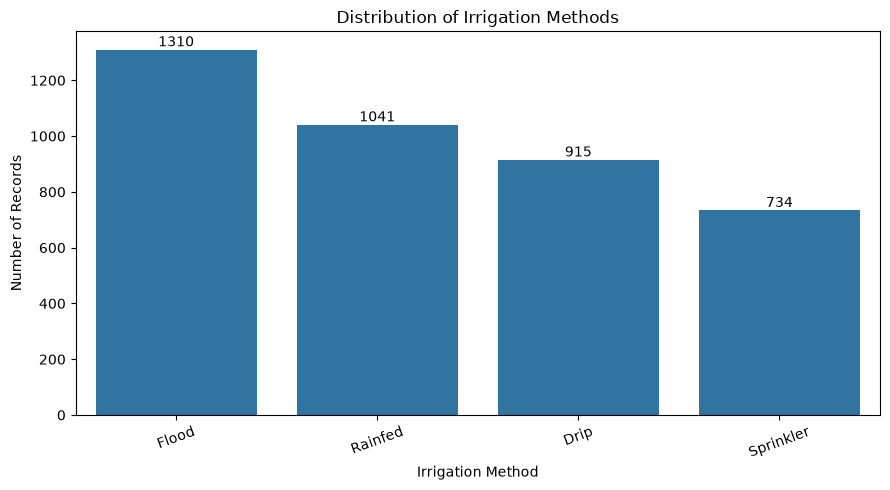

In [109]:
plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=df,
    x="Irrigation_Method",
    order=df["Irrigation_Method"].value_counts().index
)

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig("../outputs/figures/irrigation_method_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [52]:
season_performance = df.groupby("Season").agg({
    "Yield_Tonnes_Ha": ["mean", "median", "std"],
    "Production_Tonnes": ["mean", "median"],
    "Revenue_INR": ["mean", "median"],
    "Profit_INR": ["mean", "median"],
    "Water_Efficiency_t_per_1000m3": ["mean", "median"]
}).round(2)

season_performance

Yield_Tonnes_Ha              Production_Tonnes        Revenue_INR  \
                  mean median   std              mean median        mean   
Season                                                                     
Kharif            5.63   1.94 14.39             46.31  13.24   710719.06   
Rabi              5.04   1.67 12.75             41.49  11.08   601526.05   
Zaid              4.64   1.46 11.27             38.89   9.97   519171.90   

                 Profit_INR           Water_Efficiency_t_per_1000m3         
          median       mean    median                          mean median  
Season                                                                      
Kharif 520196.00  178914.65  38808.00                          5.89   3.28  
Rabi   438156.00   87689.47  -3187.00                          5.19   2.74  
Zaid   373700.50  -24804.82 -62144.00                          4.41   2.30

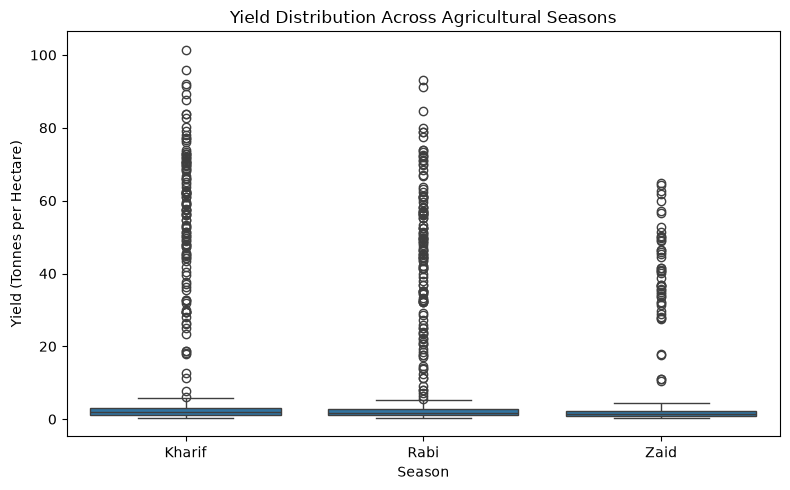

In [110]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Yield Distribution Across Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes per Hectare)")

plt.tight_layout()
plt.savefig("../outputs/figures/yield_distribution_by_season.png", dpi=300, bbox_inches="tight")
plt.show()

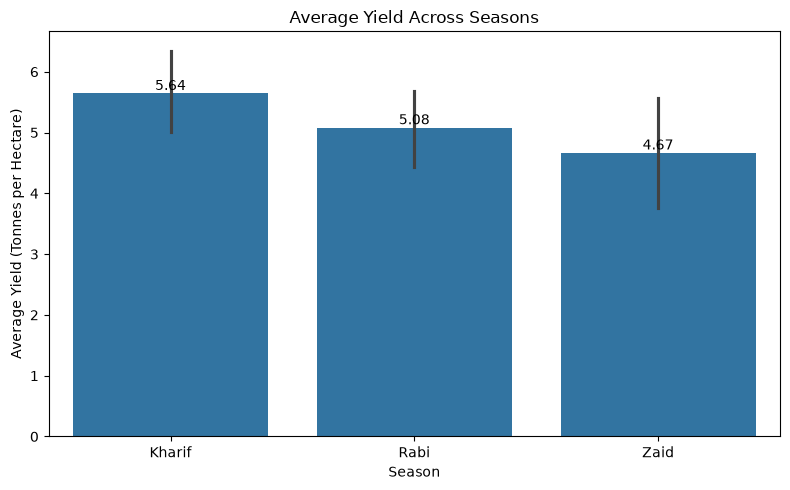

In [111]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes per Hectare)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig("../outputs/figures/average_yield_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

### Seasonal Yield Analysis

The average yield varies across the three agricultural seasons. Kharif records
the highest average yield at approximately 5.63 tonnes per hectare, followed
by Rabi at 5.04 tonnes per hectare and Zaid at 4.64 tonnes per hectare.

This indicates that Kharif has the highest average yield among the three
seasons, while Zaid has the lowest. However, the difference between the
seasonal averages is relatively moderate, so the results should not be
interpreted as evidence that one season is universally superior.

The boxplot also shows substantial variability and a large number of high-yield
observations beyond the central distribution. This indicates that yield is
strongly variable within seasons. These unusual observations should not be
removed automatically, as they may represent genuine differences in crops,
farms, environmental conditions, or agricultural practices. They will be
investigated further during the outlier and subgroup analysis.

## 7. Environmental Conditions Across Seasons

Seasonal agricultural performance can be influenced by environmental
conditions. This section compares rainfall, temperature, humidity, sunlight,
soil moisture, and soil pH across Kharif, Rabi, and Zaid seasons.

The purpose is to identify noticeable differences in environmental conditions
between seasons and examine whether these differences are associated with
variation in agricultural performance.

In [55]:
environmental_summary = df.groupby("Season").agg({
    "Rainfall_mm": ["mean", "median"],
    "Avg_Temperature_C": ["mean", "median"],
    "Humidity_pct": ["mean", "median"],
    "Sunlight_Hours_Day": ["mean", "median"],
    "Soil_Moisture_pct": ["mean", "median"],
    "Soil_pH": ["mean", "median"]
}).round(2)

environmental_summary

Rainfall_mm        Avg_Temperature_C        Humidity_pct         \
              mean median              mean median         mean median   
Season                                                                   
Kharif      849.20 853.10             28.45  28.50        71.81  71.90   
Rabi        437.62 432.20             23.49  23.50        57.89  58.10   
Zaid        304.65 288.20             31.04  31.00        52.01  52.35   

       Sunlight_Hours_Day        Soil_Moisture_pct        Soil_pH         
                     mean median              mean median    mean median  
Season                                                                    
Kharif               6.79   6.80             31.15  31.10    6.73   6.73  
Rabi                 7.59   7.60             24.07  24.00    6.67   6.67  
Zaid                 8.18   8.20             19.28  19.10    6.69   6.66

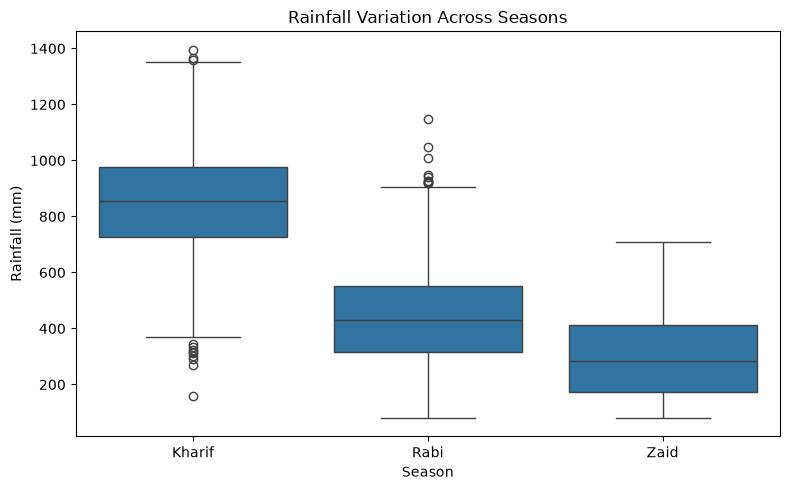

In [112]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Rainfall_mm",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Rainfall Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")

plt.tight_layout()
plt.savefig("../outputs/figures/rainfall_variation_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

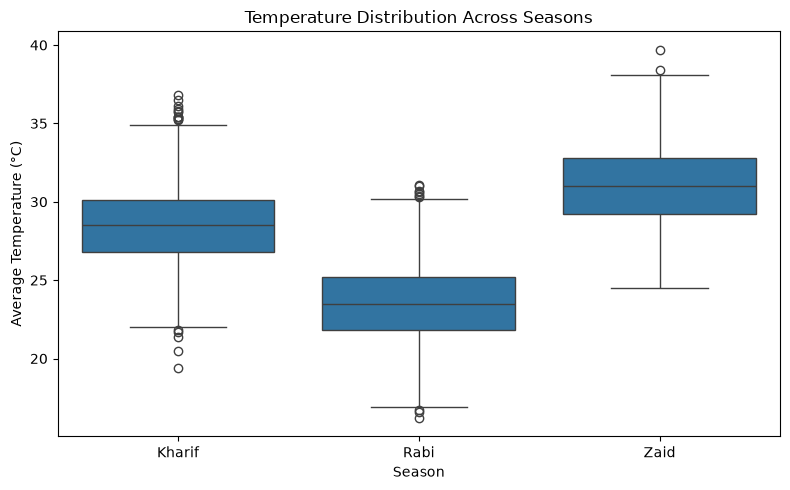

In [113]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Avg_Temperature_C",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Temperature Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Temperature (°C)")

plt.tight_layout()
plt.savefig("../outputs/figures/temperature_distribution_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

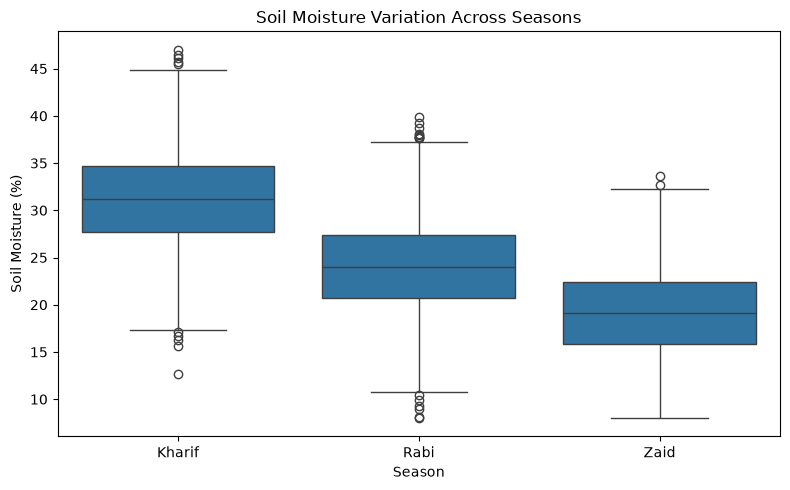

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Soil_Moisture_pct",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Soil Moisture Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/soil_moisture_variation_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

In [63]:
environment_yield_corr = df[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_Moisture_pct",
        "Soil_pH",
        "Yield_Tonnes_Ha"
    ]
].corr()

environment_yield_corr["Yield_Tonnes_Ha"].sort_values(ascending=False)
environmental_summary

Rainfall_mm        Avg_Temperature_C        Humidity_pct         \
              mean median              mean median         mean median   
Season                                                                   
Kharif      849.20 853.10             28.45  28.50        71.81  71.90   
Rabi        437.62 432.20             23.49  23.50        57.89  58.10   
Zaid        304.65 288.20             31.04  31.00        52.01  52.35   

       Sunlight_Hours_Day        Soil_Moisture_pct        Soil_pH         
                     mean median              mean median    mean median  
Season                                                                    
Kharif               6.79   6.80             31.15  31.10    6.73   6.73  
Rabi                 7.59   7.60             24.07  24.00    6.67   6.67  
Zaid                 8.18   8.20             19.28  19.10    6.69   6.66

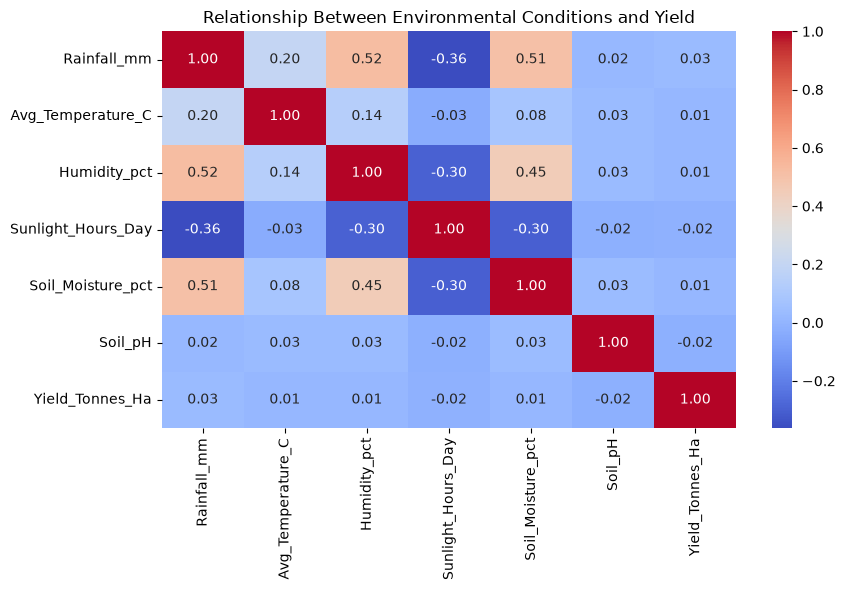

In [115]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    environment_yield_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Relationship Between Environmental Conditions and Yield")

plt.tight_layout()
plt.savefig("../outputs/figures/environment_yield_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

### Environmental Analysis Findings

The analysis shows clear differences in environmental conditions across the
three agricultural seasons. Kharif records substantially higher average
rainfall, humidity, and soil moisture than Rabi and Zaid. Rabi has the lowest
average temperature, while Zaid records the highest average temperature and
sunlight duration. Zaid also has the lowest rainfall, humidity, and soil
moisture levels. Soil pH remains relatively similar across all three seasons.

The correlation analysis shows very weak linear relationships between the
individual environmental variables and yield. Rainfall, temperature, humidity,
and soil moisture have correlations close to zero with yield, while sunlight
and soil pH also show negligible linear associations.

Therefore, although environmental conditions vary considerably across seasons,
the overall dataset does not show a strong simple linear relationship between
these individual environmental variables and yield. Other agricultural
factors may need to be considered when examining differences in agricultural
performance.

## 8. Resource Usage Across Seasons

This section examines differences in agricultural resource usage across
Kharif, Rabi, and Zaid seasons. The analysis focuses on water usage,
fertilizer application, pesticide usage, and nutrient inputs.

The purpose is to identify whether resource requirements vary across seasons
and how these differences relate to agricultural performance.

In [65]:
resource_summary = df.groupby("Season").agg({
    "Water_Used_m3": ["mean", "median"],
    "Fertilizer_kg_ha": ["mean", "median"],
    "Pesticide_Litre_ha": ["mean", "median"],
    "Nitrogen_kg_ha": ["mean", "median"],
    "Phosphorus_kg_ha": ["mean", "median"],
    "Potassium_kg_ha": ["mean", "median"]
}).round(2)

resource_summary

Water_Used_m3         Fertilizer_kg_ha        Pesticide_Litre_ha  \
                mean  median             mean median               mean   
Season                                                                    
Kharif       6102.20 4469.00           187.08 188.20               5.08   
Rabi         5846.99 4292.00           185.41 185.30               5.02   
Zaid         6419.89 4805.00           184.64 183.95               5.17   

              Nitrogen_kg_ha        Phosphorus_kg_ha        Potassium_kg_ha  \
       median           mean median             mean median            mean   
Season                                                                        
Kharif   5.18         120.02 119.80            58.10  57.40          105.30   
Rabi     5.02         120.40 120.30            57.31  57.70          103.93   
Zaid     5.18         120.53 120.15            58.13  57.45          105.42   

               
       median  
Season         
Kharif 104.80  
Rabi   104.80  
Zaid   106.30

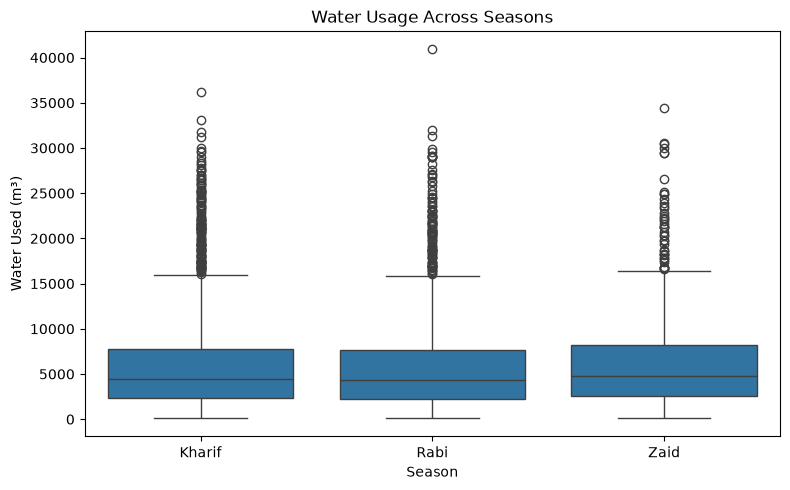

In [116]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Water_Used_m3",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")

plt.tight_layout()
plt.savefig("../outputs/figures/water_usage_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

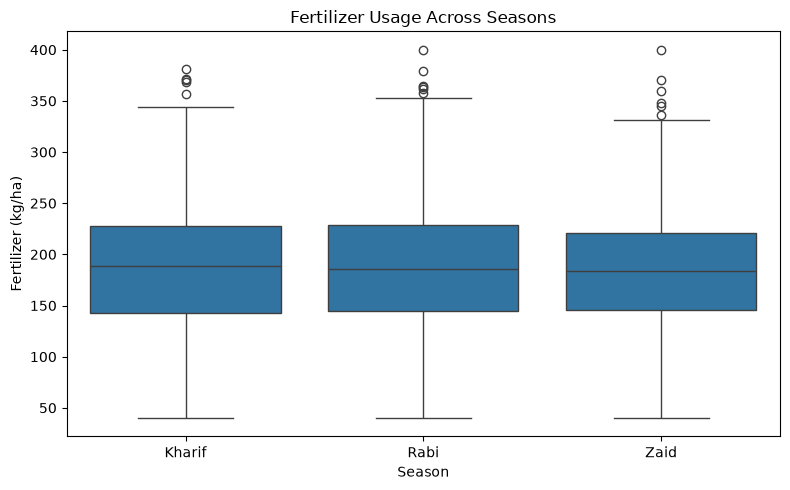

In [117]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Fertilizer_kg_ha",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Fertilizer Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")

plt.tight_layout()
plt.savefig("../outputs/figures/fertilizer_usage_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

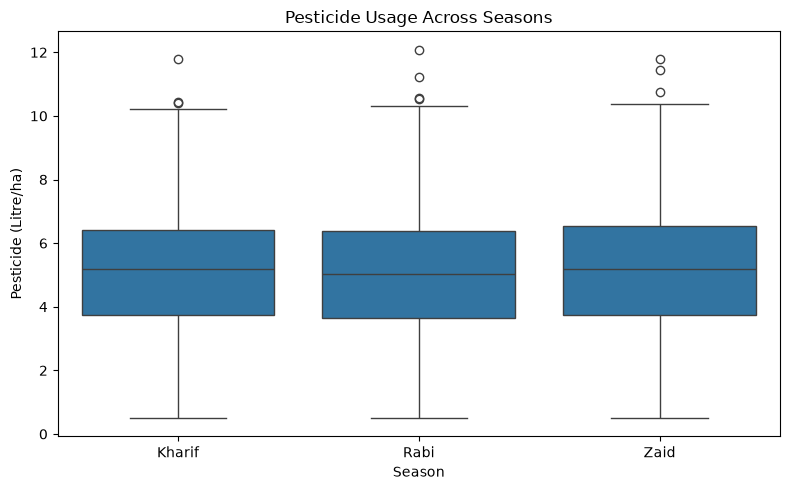

In [118]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Pesticide_Litre_ha",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Pesticide Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Pesticide (Litre/ha)")

plt.tight_layout()
plt.savefig("../outputs/figures/pesticide_usage_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

### Resource Usage Findings

Water usage shows noticeable variation across seasons. Zaid has the highest
average water usage at approximately 6,419.89 m³, followed by Kharif at
6,102.20 m³ and Rabi at 5,846.99 m³.

In contrast, fertilizer and pesticide usage are relatively similar across the
three seasons. Average fertilizer application ranges from approximately
184.64 to 187.08 kg/ha, while average pesticide usage ranges from
approximately 5.02 to 5.17 litres/ha.

Nitrogen, phosphorus, and potassium application also show relatively small
differences between seasons. Therefore, the clearest seasonal difference in
resource usage is observed in water consumption, while fertilizer, pesticide,
and nutrient usage remain comparatively consistent across seasons.

The boxplots also show substantial variation and some high-value observations,
particularly for water usage. These observations will be considered when
examining unusual patterns later in the analysis.

## 9. Economic Outcomes Across Seasons

Agricultural performance is not determined only by production and yield.
Economic outcomes are also important for evaluating the overall performance
of farming activities.

This section compares market price, total cost, revenue, and profit across
Kharif, Rabi, and Zaid seasons.

In [70]:
economic_summary = df.groupby("Season").agg({
    "Market_Price_INR_Tonne": ["mean", "median"],
    "Total_Cost_INR": ["mean", "median"],
    "Revenue_INR": ["mean", "median"],
    "Profit_INR": ["mean", "median"]
}).round(2)

economic_summary

Market_Price_INR_Tonne          Total_Cost_INR           Revenue_INR  \
                         mean   median           mean    median        mean   
Season                                                                        
Kharif               44850.91 25793.00      531804.41 524840.00   710719.06   
Rabi                 44747.97 26041.00      513836.58 506733.00   601526.05   
Zaid                 44212.03 25749.50      543976.73 534833.00   519171.90   

                 Profit_INR            
          median       mean    median  
Season                                 
Kharif 520196.00  178914.65  38808.00  
Rabi   438156.00   87689.47  -3187.00  
Zaid   373700.50  -24804.82 -62144.00

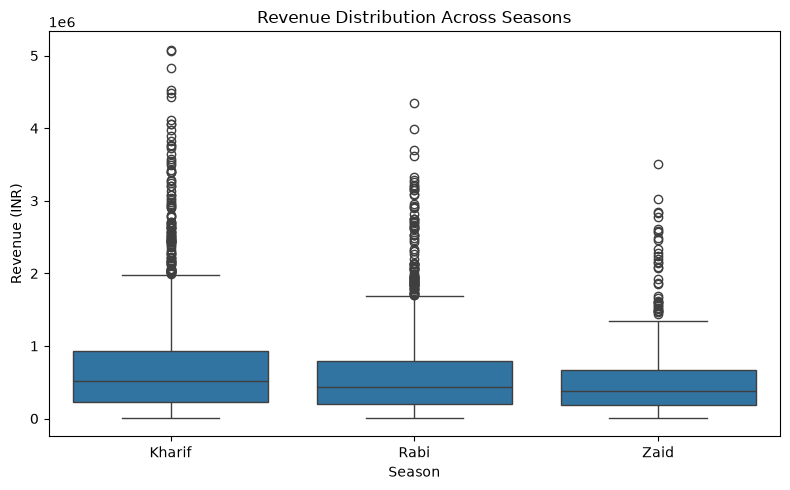

In [119]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Revenue_INR",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Revenue Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Revenue (INR)")

plt.tight_layout()
plt.savefig("../outputs/figures/revenue_distribution_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

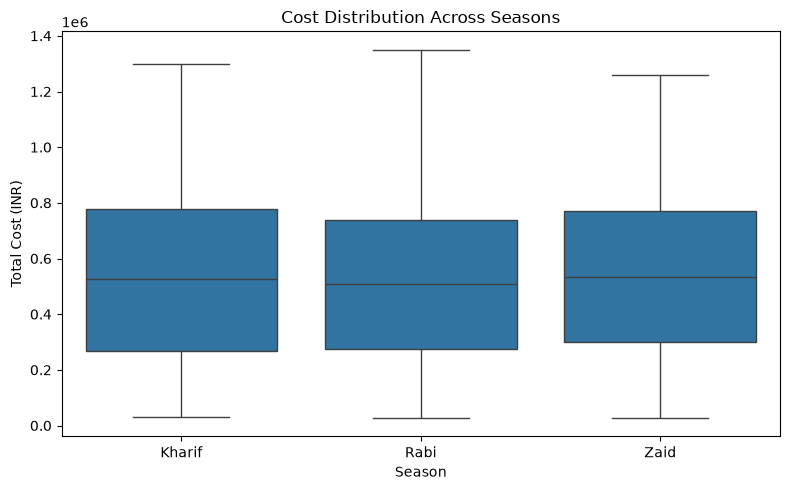

In [120]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Total_Cost_INR",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Cost Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Total Cost (INR)")

plt.tight_layout()
plt.savefig("../outputs/figures/cost_distribution_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

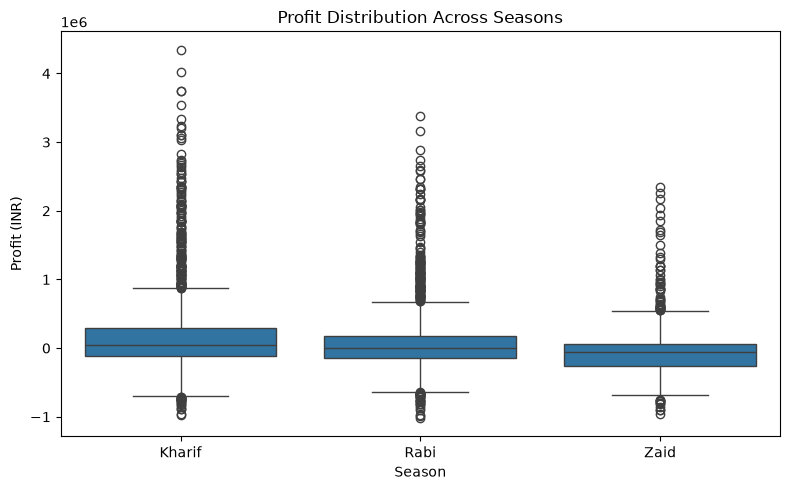

In [121]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Profit_INR",
    order=["Kharif", "Rabi", "Zaid"]
)

plt.title("Profit Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.savefig("../outputs/figures/profit_distribution_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

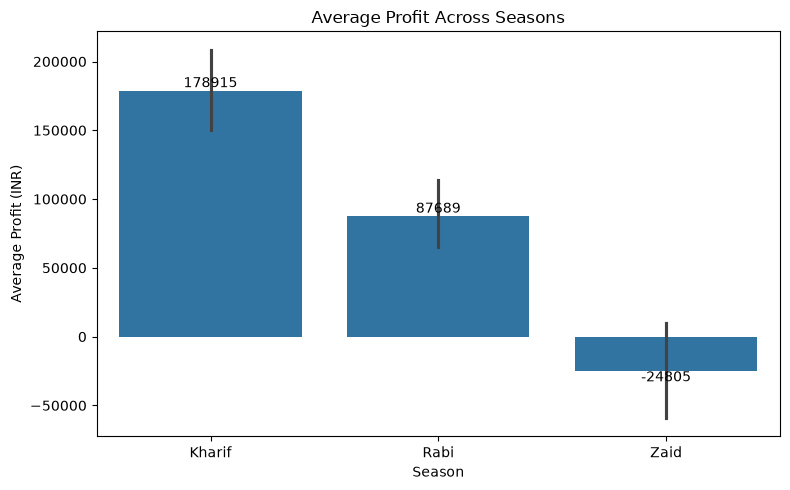

In [122]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df,
    x="Season",
    y="Profit_INR",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig("../outputs/figures/average_profit_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

### Economic Analysis Findings

The economic analysis shows clear differences in financial performance across
the three agricultural seasons.

Kharif records the highest average revenue of approximately ₹710,719 and the
highest average profit of approximately ₹178,915. Rabi records an average
revenue of approximately ₹601,526 and an average profit of approximately
₹87,689. Zaid records the lowest average revenue at approximately ₹519,172
and has a negative average profit of approximately −₹24,805.

Average market prices are relatively similar across the three seasons,
indicating that the large differences in average profit are not primarily
associated with major differences in average market price.

The median profit values are substantially lower than the corresponding mean
values, particularly for Kharif and Rabi. This indicates considerable
variation in profitability and the presence of high-profit observations that
increase the average. Zaid has a negative median profit of approximately
−₹62,144, indicating that losses are more common in the middle of the
distribution for this season.

Overall, Kharif shows the strongest economic performance, while Zaid shows
the weakest economic performance among the three seasons.

## 10. Crop and Regional Comparison

Seasonal agricultural performance may differ depending on the crop and
geographical region. This section compares crop performance across seasons
and examines whether the observed seasonal patterns are consistent across
different crop categories and regions.

In [75]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].agg(
    ["mean", "median", "std"]
).sort_values("mean", ascending=False).round(2)

crop_yield

,mean,median,std
Crop,,,
Sugarcane,46.64,47.88,21.33
Maize,2.71,2.84,1.23
Rice,2.43,2.44,1.14
Wheat,2.11,2.22,0.91
Chilli,1.54,1.56,0.78
Groundnut,1.32,1.40,0.61
Cotton,1.23,1.25,0.53
Pulses,0.92,0.94,0.43


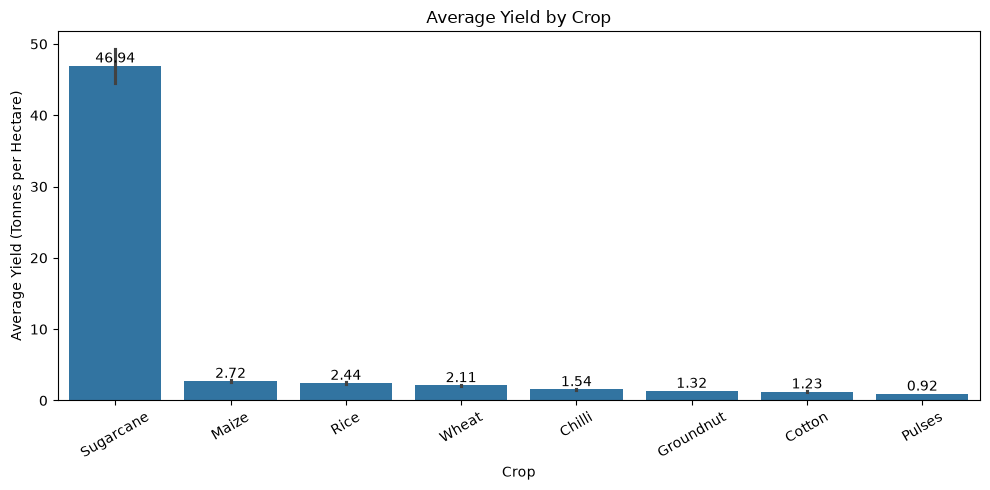

In [123]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    order=df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(
        ascending=False
    ).index,
    estimator="mean"
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes per Hectare)")
plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.savefig("../outputs/figures/average_yield_by_crop.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


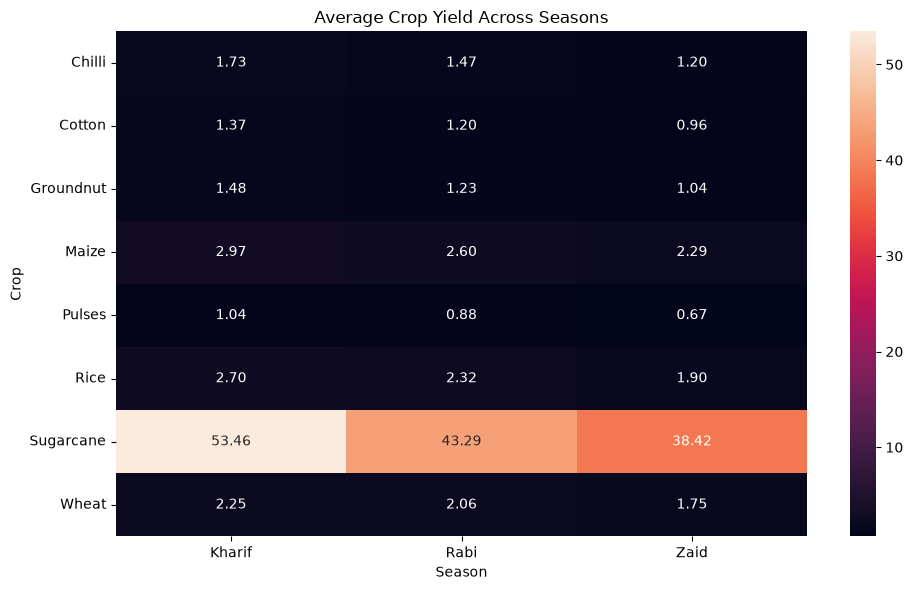

In [124]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.savefig("../outputs/figures/average_crop_yield_across_seasons.png", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
state_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="State",
    columns="Season",
    aggfunc="mean"
).round(2)

state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.45
Gujarat,6.34,5.44,4.07
Karnataka,6.46,4.57,6.62
Madhya Pradesh,5.99,3.76,5.48
Maharashtra,5.43,5.50,2.28
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.78,4.25


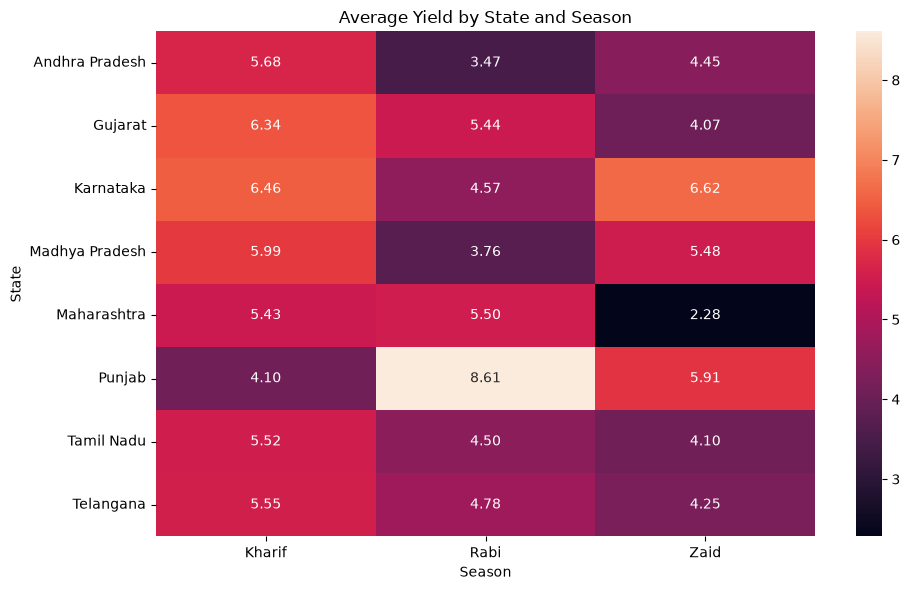

In [125]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    state_season_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by State and Season")
plt.xlabel("Season")
plt.ylabel("State")

plt.tight_layout()
plt.savefig("../outputs/figures/state_season_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Crop Yield Analysis

Average yield varies substantially across crop categories. Sugarcane records
the highest average yield at approximately 46.64 tonnes per hectare, followed
by Maize at 2.71 tonnes per hectare and Rice at 2.43 tonnes per hectare.
Pulses record the lowest average yield at approximately 0.92 tonnes per
hectare.

The crop-by-season comparison shows that Sugarcane has the highest average
yield in each of the three seasons, while the remaining crops have
considerably lower yield values.

The large difference between Sugarcane and the other crops also helps explain
the substantial variation observed in the overall yield distribution. The
differences should therefore be interpreted in the context of crop type
rather than treating all yield observations as being on the same scale."

### Crop-by-Season Analysis

The crop-by-season comparison shows a consistent seasonal pattern across all
eight crop categories. Every crop records its highest average yield during
Kharif and its lowest average yield during Zaid, with Rabi generally falling
between the two.

This pattern is particularly pronounced for Sugarcane, whose average yield
declines from 53.46 tonnes per hectare in Kharif to 43.29 tonnes per hectare
in Rabi and 38.42 tonnes per hectare in Zaid.

The consistency of this pattern across crop categories suggests that the
observed seasonal difference in yield is not limited to a single crop.
However, the magnitude of the difference varies substantially by crop.

### Regional Analysis

The regional comparison shows that seasonal yield patterns are not completely
consistent across all states.

Several states, including Gujarat, Karnataka, Madhya Pradesh, Tamil Nadu, and
Telangana, record their highest average yield during Kharif. However, Punjab
records its highest average yield during Rabi at approximately 8.61 tonnes per
hectare, while Karnataka records its highest average yield during Zaid at
approximately 6.62 tonnes per hectare.

This indicates that regional differences influence the seasonal pattern of
agricultural performance. Therefore, the overall finding that Kharif has the
highest average yield should not be interpreted as a universal pattern across
every state.

## 11. Statistical Analysis

Statistical testing is used to determine whether the observed differences in
agricultural performance across seasons are statistically significant rather
than being attributable to random variation in the sample.

A one-way ANOVA is used to compare the mean yield across Kharif, Rabi, and
Zaid seasons.

In [81]:
from scipy.stats import f_oneway

kharif_yield = df[df["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi_yield = df[df["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid_yield = df[df["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

anova_stat, p_value = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_stat, 4))
print("p-value:", p_value)

ANOVA F-statistic: 1.5439
p-value: 0.21367813841845013


### ANOVA Results

A one-way ANOVA was performed to test whether the mean yield differs
significantly across Kharif, Rabi, and Zaid seasons.

The analysis produced an F-statistic of 1.5439 and a p-value of approximately
0.2137. Since the p-value is greater than the 0.05 significance level, the
null hypothesis is not rejected.

Therefore, the analysis does not provide sufficient statistical evidence that
mean yield differs significantly across the three seasons.

Although Kharif has the highest observed average yield (5.63 tonnes per
hectare), followed by Rabi (5.04) and Zaid (4.64), these observed differences
are not statistically significant according to the ANOVA test.

## 12. Unusual Patterns and Outlier Analysis

The exploratory analysis identified substantial variation in yield and
profitability, including observations that lie far from the central
distribution.

Outlier analysis is performed to identify these unusual observations and
determine whether they represent potential data-quality issues or genuine
variation within the agricultural dataset.

In [83]:
Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of yield outliers:", len(yield_outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower bound: -1.62
Upper bound: 5.5
Number of yield outliers: 302


In [84]:
yield_outliers[
    [
        "State",
        "District",
        "Crop",
        "Season",
        "Farm_Area_Hectares",
        "Yield_Tonnes_Ha"
    ]
].sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
).head(20)

,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha
1715,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79
3525,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13
1464,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98
3523,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46
2782,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32
644,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34
2847,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76
357,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75
1178,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79


In [87]:
outlier_crop_summary = (
    yield_outliers["Crop"]
    .value_counts()
    .to_frame("Outlier_Count")
)

outlier_crop_summary["Percentage"] = (
    outlier_crop_summary["Outlier_Count"]
    / len(yield_outliers) * 100
).round(2)

outlier_crop_summary

,Outlier_Count,Percentage
Crop,,
Sugarcane,293,97.02
Maize,7,2.32
Rice,2,0.66


In [88]:
print("Total yield outliers:", len(yield_outliers))
print("\nYield outliers by crop:")
print(outlier_crop_summary)

Total yield outliers: 302

Yield outliers by crop:
           Outlier_Count  Percentage
Crop                                
Sugarcane            293       97.02
Maize                  7        2.32
Rice                   2        0.66


In [89]:
outlier_season_summary = (
    yield_outliers["Season"]
    .value_counts()
    .to_frame("Outlier_Count")
)

outlier_season_summary["Percentage"] = (
    outlier_season_summary["Outlier_Count"]
    / len(yield_outliers) * 100
).round(2)

outlier_season_summary

,Outlier_Count,Percentage
Season,,
Kharif,129,42.72
Rabi,124,41.06
Zaid,49,16.23


### Yield Outlier Analysis

The outlier analysis identified a number of unusually high yield
observations. Inspection of the highest-yield records shows that these
observations are predominantly associated with Sugarcane.

This finding is consistent with the crop-level analysis, where Sugarcane
recorded a substantially higher average yield than the other crop
categories. Therefore, the extreme yield observations should not be
automatically treated as data errors or removed from the dataset.

Instead, the outliers appear to be strongly associated with differences in
crop yield characteristics. The original observations are therefore retained
for subsequent analysis.

In [90]:
Q1_profit = df["Profit_INR"].quantile(0.25)
Q3_profit = df["Profit_INR"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = df[
    (df["Profit_INR"] < lower_profit) |
    (df["Profit_INR"] > upper_profit)
]

print("Q1:", round(Q1_profit, 2))
print("Q3:", round(Q3_profit, 2))
print("IQR:", round(IQR_profit, 2))
print("Lower bound:", round(lower_profit, 2))
print("Upper bound:", round(upper_profit, 2))
print("Number of profit outliers:", len(profit_outliers))

Q1: -148731.75
Q3: 216187.75
IQR: 364919.5
Lower bound: -696111.0
Upper bound: 763567.0
Number of profit outliers: 404


In [91]:
profit_outliers[
    [
        "State",
        "District",
        "Crop",
        "Season",
        "Yield_Tonnes_Ha",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR"
    ]
].sort_values(
    "Profit_INR",
    ascending=False
).head(20)

,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
2236,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,712027,4345421
626,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,1059050,4021850
3425,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,745161,3740099
1690,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,784135,3738329
247,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,1283161,3542204
357,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,972119,3378879
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,1097878,3330582
1930,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,875331,3232970
3983,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,844264,3211345
263,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,828217,3159447


In [92]:
print("Highest-profit outliers:")

profit_outliers[
    [
        "State",
        "District",
        "Crop",
        "Season",
        "Yield_Tonnes_Ha",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR"
    ]
].sort_values(
    "Profit_INR",
    ascending=False
).head(10)

Highest-profit outliers:


,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
2236,Punjab,Rajkot,Chilli,Kharif,3.90,5057448,712027,4345421
626,Maharashtra,Warangal,Chilli,Kharif,2.92,5080900,1059050,4021850
3425,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,4485260,745161,3740099
1690,Karnataka,Warangal,Chilli,Kharif,3.01,4522464,784135,3738329
247,Maharashtra,Krishna,Chilli,Kharif,3.09,4825365,1283161,3542204
357,Punjab,Warangal,Sugarcane,Rabi,84.75,4350998,972119,3378879
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,4428460,1097878,3330582
1930,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,4108301,875331,3232970
3983,Gujarat,Nashik,Chilli,Kharif,3.02,4055609,844264,3211345
263,Maharashtra,Ludhiana,Chilli,Rabi,2.53,3987664,828217,3159447


In [93]:
print("Largest-loss outliers:")

profit_outliers[
    [
        "State",
        "District",
        "Crop",
        "Season",
        "Yield_Tonnes_Ha",
        "Revenue_INR",
        "Total_Cost_INR",
        "Profit_INR"
    ]
].sort_values(
    "Profit_INR",
    ascending=True
).head(10)

Largest-loss outliers:


,State,District,Crop,Season,Yield_Tonnes_Ha,Revenue_INR,Total_Cost_INR,Profit_INR
780,Andhra Pradesh,Ludhiana,Groundnut,Rabi,0.30,280139,1299362,-1019223
2210,Andhra Pradesh,Raichur,Wheat,Rabi,0.30,102497,1097692,-995195
3625,Punjab,Krishna,Maize,Rabi,0.97,226503,1207553,-981050
2182,Andhra Pradesh,Krishna,Rice,Kharif,1.01,320865,1297725,-976860
104,Gujarat,Krishna,Wheat,Zaid,0.30,98792,1063989,-965197
3394,Gujarat,Erode,Wheat,Kharif,0.30,99644,1063040,-963396
2730,Madhya Pradesh,Ludhiana,Rice,Rabi,1.74,89197,995279,-906082
1311,Punjab,Rajkot,Rice,Zaid,0.45,163084,1065824,-902740
585,Telangana,Warangal,Cotton,Zaid,0.30,198300,1094030,-895730
3090,Karnataka,Ludhiana,Maize,Kharif,0.41,109026,999667,-890641


In [94]:
profit_outlier_crop = profit_outliers["Crop"].value_counts()
profit_outlier_season = profit_outliers["Season"].value_counts()

print("Profit outliers by crop:")
print(profit_outlier_crop)

print("\nProfit outliers by season:")
print(profit_outlier_season)

Profit outliers by crop:
Crop
Chilli       161
Sugarcane    146
Cotton        33
Maize         17
Rice          14
Pulses        12
Wheat         11
Groundnut     10
Name: count, dtype: int64

Profit outliers by season:
Season
Kharif    211
Rabi      150
Zaid       43
Name: count, dtype: int64


## 13. Key Findings

The analysis of 4,000 agricultural records across three seasons produced the
following major findings:

1. Kharif recorded the highest average yield at approximately 5.63 tonnes per
   hectare, followed by Rabi at 5.04 and Zaid at 4.64 tonnes per hectare.

2. Environmental conditions differed considerably across seasons. Kharif had
   the highest rainfall, humidity, and soil moisture, while Zaid had the
   highest temperature and sunlight duration.

3. The correlation analysis showed very weak linear relationships between the
   individual environmental variables and yield in the overall dataset.

4. Water usage showed the clearest seasonal difference among the resources
   examined. Zaid had the highest average water usage, while fertilizer,
   pesticide, nitrogen, phosphorus, and potassium usage were relatively
   similar across seasons.

5. Kharif showed the strongest economic performance, with the highest average
   revenue and profit. Zaid recorded a negative average profit.

6. Crop type was associated with substantial differences in yield. Sugarcane
   recorded a much higher average yield than the other crops.

7. All eight crops recorded their highest average yield during Kharif and
   lowest average yield during Zaid in the crop-by-season comparison.

8. Seasonal patterns were not completely consistent across regions. While
   several states recorded their highest average yield during Kharif, Punjab
   performed best during Rabi and Karnataka performed best during Zaid.

9. Outlier analysis identified substantial variation in yield and profit.
   High-yield observations were predominantly associated with Sugarcane,
   indicating that crop differences contribute strongly to the extreme yield
   values.

10. A one-way ANOVA produced an F-statistic of 1.5439 and a p-value of
    approximately 0.2137. Therefore, the observed differences in mean yield
    across seasons were not statistically significant at the 0.05 level.

## 14. Data-Driven Recommendations

Based on the analysis, the following recommendations can be made:

1. Seasonal planning should consider crop and regional differences rather
   than assuming that one season will perform equally well everywhere.

2. Water management should receive particular attention during Zaid, which
   recorded the highest average water usage while also having the lowest
   average yield and negative average profit.

3. Resource planning should be evaluated together with agricultural outcomes.
   Since fertilizer and pesticide usage were relatively similar across
   seasons, increasing resource application alone should not automatically be
   assumed to improve performance.

4. Crop-specific planning is important because yield levels differ
   substantially between crops. Sugarcane, in particular, operates at a very
   different yield scale from the other crops in the dataset.

5. Regional seasonal performance should be considered when making agricultural
   plans. The analysis showed that some states did not follow the overall
   Kharif-dominant seasonal pattern.

6. Profitability should be monitored alongside yield. The results show that
   higher agricultural performance does not automatically translate into
   similar economic outcomes across all seasons.

7. Extreme observations should be investigated rather than automatically
   removed. The analysis indicates that many unusual yield observations are
   associated with crop-level differences, while profitability contains both
   high-profit and loss-making observations.

## 15. Conclusion

This project analyzed 4,000 agricultural records to understand seasonal
differences in agricultural performance. The analysis examined yield,
environmental conditions, resource usage, economic outcomes, crop
performance, regional differences, and unusual observations.

Kharif recorded the highest average yield and the strongest average economic
performance, while Zaid recorded the lowest average yield and negative
average profit. Environmental and resource conditions also varied across
seasons, with Kharif showing substantially higher rainfall and soil moisture
and Zaid showing higher temperature, sunlight, and water usage.

Crop and regional comparisons showed that seasonal performance cannot be
interpreted independently of crop type and geographical region. Sugarcane
recorded substantially higher yields than the other crops, while regional
results showed that some states followed different seasonal patterns.

Although Kharif had the highest observed average yield, the one-way ANOVA
indicated that the differences in mean yield across seasons were not
statistically significant at the 0.05 level. Therefore, the findings should
be interpreted as observed patterns in the dataset rather than definitive
evidence that one season universally produces higher yields.

Overall, the analysis demonstrates the importance of considering seasonal,
crop, regional, resource, and economic factors together when evaluating
agricultural performance. The findings can support more targeted seasonal
planning and further investigation of crop- and region-specific performance.

In [95]:
final_summary = pd.DataFrame({
    "Metric": [
        "Number of Records",
        "Number of Variables",
        "Highest Average Yield Season",
        "Highest Average Yield",
        "Highest Average Profit Season",
        "Highest Average Profit",
        "Lowest Average Profit Season",
        "Lowest Average Profit",
        "Yield ANOVA p-value"
    ],
    "Result": [
        len(df),
        df.shape[1],
        "Kharif",
        "5.63 tonnes/ha",
        "Kharif",
        "₹178,914.65",
        "Zaid",
        "₹-24,804.82",
        "0.2137"
    ]
})

final_summary

,Metric,Result
0,Number of Records,4000
1,Number of Variables,28
2,Highest Average Yield Season,Kharif
3,Highest Average Yield,5.63 tonnes/ha
4,Highest Average Profit Season,Kharif
5,Highest Average Profit,"₹178,914.65"
6,Lowest Average Profit Season,Zaid
7,Lowest Average Profit,"₹-24,804.82"
8,Yield ANOVA p-value,0.2137
